In [1]:
# Install required packages (if needed)
# !pip3 install pandas numpy matplotlib seaborn scikit-learn tqdm requests -q

In [12]:
# Ollama API setup and imports
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
import time
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, classification_report
import numpy as np
import re

print("✓ Libraries imported successfully")
print("✓ Ollama will be used for LLM inference")

print("\n" + "=" * 80)
print("SETUP COMPLETE - FEW-SHOT RISK ASSESSMENT")
print("=" * 80)
print("Models configured:")
print("  • R4: Llama3.1:8b (Ollama - Local - Few-Shot)")
print("  • R5: Qwen3:8b (Ollama - Local - Few-Shot)")
print("  • R6: DeepSeek-R1:8b (Ollama - Local - Few-Shot)")
print("=" * 80)

✓ Libraries imported successfully
✓ Ollama will be used for LLM inference

SETUP COMPLETE - FEW-SHOT RISK ASSESSMENT
Models configured:
  • R4: Llama3.1:8b (Ollama - Local - Few-Shot)
  • R5: Qwen3:8b (Ollama - Local - Few-Shot)
  • R6: DeepSeek-R1:8b (Ollama - Local - Few-Shot)


## 1. Load Dataset

In [3]:
# Load the 100% agreement dataset (highest quality)
data_path = "../../../Startified Data PMP/Processed Data/processed_data.csv"

df = pd.read_csv(data_path)
df.rename(columns={"sentiment": "true_risk"}, inplace=True)
df.rename(columns={"sentences": "sentence"}, inplace=True)

print(f"Dataset loaded: {len(df)} sentences")

# Display sample
print("\n" + "=" * 80)
print("Sample sentences:")
print("=" * 80)
display(df.sample(5, random_state=42))

Dataset loaded: 210 sentences

Sample sentences:


,sentence,true_risk,word_count,char_length
30,Tallink Silja attributes the significant drop ...,negative,46,267
172,"ADP News - Feb 13 , 2009 - Finnish retailer Ke...",negative,43,207
84,20 October 2010 - Finnish environmental manage...,negative,43,237
199,"Finnair 's Tallinn-based subsidiary , Aero AS ...",negative,31,178
60,MegaFon 's subscriber base increased 16.1 % in...,positive,50,246


## 2. Few-Shot Examples

Carefully curated examples (2 positive, 2 negative, 1 neutral) representing typical financial risk patterns.

In [4]:
# Curated few-shot examples for RISK ASSESSMENT
FEW_SHOT_EXAMPLES = [
    {
        "sentence": "Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007.",
        "risk": "positive",
        "rationale": "Profit growth reduces business risk and indicates improved financial resilience for investors.",
    },
    {
        "sentence": "Net sales increased by 18.5% to EUR 167.8 million compared to the previous year.",
        "risk": "positive",
        "rationale": "Strong revenue growth signals lower business risk and increases company's ability to weather market challenges.",
    },
    {
        "sentence": "The company reported a net loss of EUR 2.5 million compared to a profit of EUR 1.2 million in the previous quarter.",
        "risk": "negative",
        "rationale": "Shift from profit to loss represents increased financial risk and deteriorating business fundamentals that threaten shareholder value.",
    },
    {
        "sentence": "Sales decreased by 15% year-over-year due to weakening demand in key markets.",
        "risk": "negative",
        "rationale": "Significant revenue decline signals elevated operational risk, market challenges, and potential liquidity concerns for investors.",
    },
    {
        "sentence": "The company announced the appointment of a new chief financial officer effective next month.",
        "risk": "neutral",
        "rationale": "Executive changes are routine corporate announcements without direct implications for immediate investment risk.",
    },
]

print("Few-Shot Examples for RISK ASSESSMENT:")
print("=" * 80)
for i, ex in enumerate(FEW_SHOT_EXAMPLES, 1):
    print(f"\nExample {i} [{ex['risk'].upper()}]:")
    print(f"Sentence: {ex['sentence']}")
    print(f"Risk Assessment: {ex['rationale']}")

Few-Shot Examples for RISK ASSESSMENT:

Example 1 [POSITIVE]:
Sentence: Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007.
Risk Assessment: Profit growth reduces business risk and indicates improved financial resilience for investors.

Example 2 [POSITIVE]:
Sentence: Net sales increased by 18.5% to EUR 167.8 million compared to the previous year.
Risk Assessment: Strong revenue growth signals lower business risk and increases company's ability to weather market challenges.

Example 3 [NEGATIVE]:
Sentence: The company reported a net loss of EUR 2.5 million compared to a profit of EUR 1.2 million in the previous quarter.
Risk Assessment: Shift from profit to loss represents increased financial risk and deteriorating business fundamentals that threaten shareholder value.

Example 4 [NEGATIVE]:
Sentence: Sales decreased by 15% year-over-year due to weakening demand in key markets.
Risk Assessment: Significant revenue decline signals elevated operation

## 3. Few-Shot Prompt Design

In [ ]:
def create_few_shot_prompt(sentence):
    """
    Creates a few-shot prompt with 5 labeled examples for financial risk assessment.
    """
    examples_text = ""
    for i, ex in enumerate(FEW_SHOT_EXAMPLES, 1):
        examples_text += f"""\nExample {i}:
            Sentence: "{ex["sentence"]}"
            Analysis:
            {{
                "risk": "{ex["risk"]}",
                "confidence": 0.95,
                "rationale": "{ex["rationale"]}"
            }}
    """

    prompt = f"""You are a financial risk assessment expert specializing in investment analysis.

Analyze the following financial statement and classify its impact on investment risk as "positive", "negative", or "neutral".

Guidelines:
- Positive: Opportunity signals that reduce investment risk (revenue growth, profit increase, market expansion)
- Negative: Threat signals that increase investment risk (losses, declining sales, operational challenges)
- Neutral: Informational content with no direct risk implications

Here are 5 examples to learn from:
{examples_text}

Now classify this new statement:
Sentence: "{sentence}"

Provide your response in JSON format:
{{
    "risk": "positive/negative/neutral",
    "confidence": 0.0-1.0,
    "rationale": "Brief explanation in one sentence of how this affects investment risk"
}}
"""
    return prompt


# Test prompt
print("=" * 80)
print("FEW-SHOT PROMPT EXAMPLE (RISK ASSESSMENT)")
print("=" * 80)
print(create_few_shot_prompt(df["sentence"].iloc[0]))

FEW-SHOT PROMPT EXAMPLE (RISK ASSESSMENT)
You are a financial risk assessment expert specializing in investment analysis.

Analyze the following financial statement and classify its impact on investment risk as "positive", "negative", or "neutral".

Guidelines:
- Positive: Opportunity signals that reduce investment risk (revenue growth, profit increase, market expansion)
- Negative: Threat signals that increase investment risk (losses, declining sales, operational challenges)
- Neutral: Informational content with no direct risk implications

Here are 5 examples to learn from:

Example 1:
            Sentence: "Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007."
            Analysis:
            {
                "risk": "positive",
                "confidence": 0.95,
                "rationale": "Profit growth reduces business risk and indicates improved financial resilience for investors."
            }
    
Example 2:
            Sentence: "Net 

## 4. Model Inference Functions

In [6]:
# Ollama API configuration
OLLAMA_BASE_URL = "http://localhost:11434/api/generate"


def call_ollama(model_name, prompt, temperature=0.0):
    """Generic function to call Ollama API for any model"""
    max_retries = 3
    for attempt in range(max_retries):
        try:
            response = requests.post(
                OLLAMA_BASE_URL,
                json={
                    "model": model_name,
                    "prompt": prompt,
                    "temperature": temperature,
                    "stream": False,
                },
                timeout=120,
            )
            if response.status_code == 200:
                return response.json().get("response", "")
            else:
                print(f"⚠️  Ollama API error: {response.status_code}")
                if attempt < max_retries - 1:
                    time.sleep(2**attempt)
                    continue
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2**attempt)
                continue
            print(f"Error calling Ollama: {e}")
            return None
    return None


def call_llama(prompt, temperature=0.0):
    """Call Llama3.1:8b via Ollama API (R4)"""
    return call_ollama("llama3.1:8b", prompt, temperature)


def call_qwen(prompt, temperature=0.0):
    """Call Qwen3:8b via Ollama API (R5)"""
    return call_ollama("qwen3:8b", prompt, temperature)


def call_deepseek(prompt, temperature=0.0):
    """Call DeepSeek-R1:8b via Ollama API (R6)"""
    return call_ollama("deepseek-r1:8b", prompt, temperature)

def parse_response(response_text):
    """Robustly parse JSON response, handling conversational filler and markdown blocks."""
    if not response_text:
        return None
        
    try:
        # 1. Try to extract from Markdown code blocks (```json ... ```)
        if "```json" in response_text:
            json_str = response_text.split("```json")[1].split("```")[0].strip()
        elif "```" in response_text:
            json_str = response_text.split("```")[1].strip()
        else:
            # 2. Use Regex to find the first '{' and last '}'
            # This is the "magic" fix for Llama/DeepSeek chatter
            match = re.search(r'(\{.*\})', response_text, re.DOTALL)
            if match:
                json_str = match.group(1).strip()
            else:
                json_str = response_text.strip()

        result = json.loads(json_str)
        
        # Handle 'sentiment' vs 'risk' key mapping
        if 'sentiment' in result and 'risk' not in result:
            result['risk'] = result['sentiment']
        
        return result

    except Exception as e:
        # 3. Fallback logic (Keep your existing keyword search)
        response_lower = response_text.lower()
        if "positive" in response_lower and "negative" not in response_lower:
            return {"risk": "positive", "confidence": 0.5, "rationale": "Regex fail; keyword fallback"}
        elif "negative" in response_lower:
            return {"risk": "negative", "confidence": 0.5, "rationale": "Regex fail; keyword fallback"}
        elif "neutral" in response_lower:
            return {"risk": "neutral", "confidence": 0.5, "rationale": "Regex fail; keyword fallback"}
        return None
    
print("✓ Model inference functions defined")
print("  • call_llama() - Llama3.1:8b (R4)")
print("  • call_qwen() - Qwen3:8b (R5)")
print("  • call_deepseek() - DeepSeek-R1:8b (R6)")
print("  • parse_response() - JSON parser")


✓ Model inference functions defined
  • call_llama() - Llama3.1:8b (R4)
  • call_qwen() - Qwen3:8b (R5)
  • call_deepseek() - DeepSeek-R1:8b (R6)
  • parse_response() - JSON parser


In [7]:
### New function - 

REQUIRED_KEYS = {"risk", "confidence", "rationale"}
VALID_RISK_VALUES = {"positive", "negative", "neutral"}

def parse_response(response_text):
    """Parse JSON response from model"""
    try:
        if "```json" in response_text:
            json_str = response_text.split("```json")[1].split("```")[0].strip()
        elif "```" in response_text:
            json_str = response_text.split("```")[1].strip()
        else:
            json_str = response_text.strip()

        # Find the first { ... } block in case there's leading text
        start = json_str.find("{")
        end = json_str.rfind("}") + 1
        if start != -1 and end > start:
            json_str = json_str[start:end]

        result = json.loads(json_str)

        # If model returned a list, take the first element
        if isinstance(result, list):
            result = result[0]

        # Validate only the 3 required keys exist and risk is valid
        if not REQUIRED_KEYS.issubset(result.keys()):
            raise ValueError(f"Missing required keys. Got: {set(result.keys())}")
        if result["risk"] not in VALID_RISK_VALUES:
            raise ValueError(f"Invalid risk value: {result['risk']}")

        # Return only the 3 keys, stripping any extra fields like "company"
        return {k: result[k] for k in REQUIRED_KEYS}

    except Exception as e:
        print("Parse error: {}".format(str(e)[:100]))
        print("Raw response was:\n{}".format(response_text))
        response_lower = response_text.lower() if response_text else ""
        if "positive" in response_lower and "negative" not in response_lower:
            return {"risk": "positive", "confidence": 0.5, "rationale": "Parsed from text"}
        elif "negative" in response_lower:
            return {"risk": "negative", "confidence": 0.5, "rationale": "Parsed from text"}
        elif "neutral" in response_lower:
            return {"risk": "neutral", "confidence": 0.5, "rationale": "Parsed from text"}
        return None

In [8]:
# Test API calls with a sample sentence
test_sentence = df["sentence"].iloc[0]
test_prompt = create_few_shot_prompt(test_sentence)

print("=" * 80)
print("Testing llama3.1:8b...")
print("=" * 80)
llama3_response = call_llama(test_prompt)#, model_name= "llama3.1:8b" )
if llama3_response:
    print(f"✓ Response received (length: {len(llama3_response)})")
    print(f"Response: {llama3_response[:500]}")
    try:
        parsed = json.loads(llama3_response)
        print(f"✓ Parsed successfully: {parsed}")
    except Exception as e:
        print(f"✗ Failed to parse response as JSON: {e}")
else:
    print("✗ llama3.1:8b call failed - no response received")

Testing llama3.1:8b...
✓ Response received (length: 285)
Response: Here is the analysis:

```
{
    "risk": "neutral",
    "confidence": 0.85,
    "rationale": "The listing of supported Nokia phones is an informational disclosure without direct implications for immediate investment risk, but may indicate a stable or expanded product portfolio."
}
```
✗ Failed to parse response as JSON: Expecting value: line 1 column 1 (char 0)


In [9]:
print("\n" + "=" * 80)
print("Testing qwen3:8b...")
print("=" * 80)
qwen3_response = call_qwen(test_prompt)
if qwen3_response:
    print(f"✓ Response received (length: {len(qwen3_response)})")
    print(f"Response: {qwen3_response[:500]}")
    parsed = parse_response(qwen3_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ qwen3:8b call failed - no response received")


Testing qwen3:8b...
✓ Response received (length: 247)
Response: {
    "risk": "neutral",
    "confidence": 0.95,
    "rationale": "The statement provides product support information without indicating financial performance, market trends, or operational risks that would directly impact investment decisions."
}
✓ Parsed successfully: {'risk': 'neutral', 'rationale': 'The statement provides product support information without indicating financial performance, market trends, or operational risks that would directly impact investment decisions.', 'confidence': 0.95}


In [10]:
print("\n" + "=" * 80)
print("Testing deepseek-r1:8b...")
print("=" * 80)
deepseek_response = call_deepseek(test_prompt)
if deepseek_response:
    print(f"✓ Response received (length: {len(deepseek_response)})")
    print(f"Response: {deepseek_response[:500]}")
    parsed = parse_response(deepseek_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ deepseek-r1:8b call failed - no response received")


Testing deepseek-r1:8b...
✓ Response received (length: 265)
Response: ```json
{
    "risk": "neutral",
    "confidence": 0.95,
    "rationale": "A list of supported Nokia phones provides informational content without indicating any change in financial performance or business strategy that would directly impact investment risk."
}
```
✓ Parsed successfully: {'risk': 'neutral', 'rationale': 'A list of supported Nokia phones provides informational content without indicating any change in financial performance or business strategy that would directly impact investment risk.', 'confidence': 0.95}


## 5. Run Experiments

### R4: Llama3.1:8b (Few-Shot)

In [13]:
# R4: Llama3.1:8b
print("=" * 80)
print("Running R4: Llama3.1:8b (Few-Shot)")
print("=" * 80)
r4_results = []

for idx, row in tqdm(df.iterrows(), total=len(df),  desc="R4 Progress"):
    prompt = create_few_shot_prompt(row["sentence"])
    response = call_llama(prompt)

    if response:
        parsed = parse_response(response)
        if parsed:
            r4_results.append(
                {
                    "sentence": row["sentence"],
                    "true_risk": row["true_risk"],
                    "predicted_risk": parsed.get("risk", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                }
            )
        else:
            r4_results.append(
                {
                    "sentence": row["sentence"],
                    "true_risk": row["true_risk"],
                    "predicted_risk": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                }
            )
    else:
        r4_results.append(
            {
                "sentence": row["sentence"],
                "true_risk": row["true_risk"],
                "predicted_risk": "error",
                "confidence": 0,
                "rationale": "API call failed",
            }
        )

    time.sleep(0.5)

r4_df = pd.DataFrame(r4_results)
print(f"\n✓ R4 completed: {len(r4_df)} predictions")
print(
    f"  Valid predictions: {len(r4_df[r4_df['predicted_risk'].isin(['positive', 'negative', 'neutral'])])}"
)
print(f"  Errors: {len(r4_df[r4_df['predicted_risk'] == 'error'])}")
display(r4_df.head())

Running R4: Llama3.1:8b (Few-Shot)


R4 Progress: 100%|██████████| 210/210 [21:08<00:00,  6.04s/it]


✓ R4 completed: 210 predictions
  Valid predictions: 210
  Errors: 0


,sentence,true_risk,predicted_risk,confidence,rationale
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,negative,0.60,Listing a large number of supported Nokia phon...
1,Our customers come from the following countrie...,neutral,neutral,0.80,This statement provides information on custome...
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.85,The announcement of a change in corporate owne...
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.80,Ownership of sports teams and arenas is a non-...
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.80,This announcement provides administrative clar...


In [14]:
print("True vs Predicted Risk:")
print(r4_df["true_risk"].value_counts())
print(r4_df["predicted_risk"].value_counts())

True vs Predicted Risk:
true_risk
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_risk
negative    94
positive    72
neutral     44
Name: count, dtype: int64


### R5: Qwen3:8b (Few-Shot)

In [15]:
# R5: Qwen3:8b
print("\n" + "=" * 80)
print("Running R5: Qwen3:8b (Few-Shot)")
print("=" * 80)
r5_results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="R5 Progress"):
    prompt = create_few_shot_prompt(row["sentence"])
    response = call_qwen(prompt)

    if response:
        parsed = parse_response(response)
        if parsed:
            r5_results.append(
                {
                    "sentence": row["sentence"],
                    "true_risk": row["true_risk"],
                    "predicted_risk": parsed.get("risk", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                }
            )
        else:
            r5_results.append(
                {
                    "sentence": row["sentence"],
                    "true_risk": row["true_risk"],
                    "predicted_risk": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                }
            )
    else:
        r5_results.append(
            {
                "sentence": row["sentence"],
                "true_risk": row["true_risk"],
                "predicted_risk": "error",
                "confidence": 0,
                "rationale": "API call failed",
            }
        )

    time.sleep(0.5)

r5_df = pd.DataFrame(r5_results)
print(f"\n✓ R5 completed: {len(r5_df)} predictions")
print(
    f"  Valid predictions: {len(r5_df[r5_df['predicted_risk'].isin(['positive', 'negative', 'neutral'])])}"
)
print(f"  Errors: {len(r5_df[r5_df['predicted_risk'] == 'error'])}")
display(r5_df.head())


Running R5: Qwen3:8b (Few-Shot)


R5 Progress: 100%|██████████| 210/210 [1:56:14<00:00, 33.21s/it] 


✓ R5 completed: 210 predictions
  Valid predictions: 210
  Errors: 0


,sentence,true_risk,predicted_risk,confidence,rationale
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,neutral,0.95,Listing supported phone models provides operat...
1,Our customers come from the following countrie...,neutral,neutral,0.95,The statement provides geographic customer dis...
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.95,Disclosure of ownership structure and sharehol...
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.95,Information about company assets and business ...
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.95,The statement describes a structural change in...


In [16]:
print("True vs Predicted Risk:")
print(r5_df["true_risk"].value_counts())
print(r5_df["predicted_risk"].value_counts())

True vs Predicted Risk:
true_risk
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_risk
neutral     75
positive    72
negative    63
Name: count, dtype: int64


### R6: DeepSeek-R1:8b

In [17]:
# R6: DeepSeek-R1:8b
print("\n" + "=" * 80)
print("Running R6: DeepSeek-R1:8b (Few-Shot)")
print("=" * 80)
# R6: DeepSeek-R1:8b with few-shot examples

r6_results = []

for idx, row in tqdm(df.iterrows(), total=len(df),  desc="R6 Progress"):    
    response = call_deepseek(create_few_shot_prompt(row["sentence"]))

    if response:
        parsed = parse_response(response)
        if parsed:
            r6_results.append(
                {
                    "sentence": row["sentence"],
                    "true_risk": row["true_risk"],
                    "predicted_risk": parsed.get("risk", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                }
            )
        else:
            r6_results.append(
                {
                    "sentence": row["sentence"],
                    "true_risk": row["true_risk"],
                    "predicted_risk": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                }
            )
    else:
        r6_results.append(
            {
                "sentence": row["sentence"],
                "true_risk": row["true_risk"],
                "predicted_risk": "error",
                "confidence": 0,
                "rationale": "Model inference failed",
            }
        )

    time.sleep(0.1)  # Shorter delay for local model

r6_df = pd.DataFrame(r6_results)
print(f"\n✓ R6 completed: {len(r6_df)} predictions")
print(
    f"  Valid predictions: {len(r6_df[r6_df['predicted_risk'].isin(['positive', 'negative', 'neutral'])])}"
)
print(f"  Errors: {len(r6_df[r6_df['predicted_risk'] == 'error'])}")
display(r6_df.head())


Running R6: DeepSeek-R1:8b (Few-Shot)


R6 Progress: 100%|██████████| 210/210 [1:39:40<00:00, 28.48s/it]


✓ R6 completed: 210 predictions
  Valid predictions: 210
  Errors: 0


,sentence,true_risk,predicted_risk,confidence,rationale
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,neutral,0.95,The sentence lists supported Nokia phone model...
1,Our customers come from the following countrie...,neutral,neutral,0.75,Listing customer countries provides informatio...
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.95,This statement provides factual information ab...
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.95,This statement describes the holdings of a div...
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.95,Implementation of a prior Board decision on co...


In [19]:
print("True vs Predicted Risk:")
print(r6_df["true_risk"].value_counts())
print(r6_df["predicted_risk"].value_counts())

True vs Predicted Risk:
true_risk
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_risk
positive    74
neutral     68
negative    68
Name: count, dtype: int64


## 6. Calculate Metrics

In [20]:
from sklearn.metrics import matthews_corrcoef


def calculate_metrics(df, exp_name):
    """Calculate all evaluation metrics including MCC"""
    # Check if dataframe is empty or missing required columns
    if df.empty or "predicted_risk" not in df.columns:
        print(f"⚠️ Warning: {exp_name} has no valid predictions!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": 0,
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "Macro-Recall": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )

    # Filter out errors
    valid_df = df[
        df["predicted_risk"].isin(["positive", "negative", "neutral"])
    ].copy()

    # Check if we have valid predictions
    if valid_df.empty:
        print(f"⚠️ Warning: {exp_name} has no valid predictions after filtering!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": len(df),
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "Macro-Recall": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )

    y_true = valid_df["true_risk"]
    y_pred = valid_df["predicted_risk"]

    # Calculate Matthews Correlation Coefficient
    mcc_score = matthews_corrcoef(y_true, y_pred)

    metrics = {
        "Experiment": exp_name,
        "Total Samples": len(df),
        "Valid Predictions": len(valid_df),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro"),
        "MCC": mcc_score,
    }

    # Per-class metrics
    labels = ["positive", "negative", "neutral"]
    precision_per_class = precision_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    recall_per_class = recall_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    f1_per_class = f1_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )

    for i, label in enumerate(labels):
        metrics[f"{label.capitalize()}_Precision"] = precision_per_class[i]
        metrics[f"{label.capitalize()}_Recall"] = recall_per_class[i]
        metrics[f"{label.capitalize()}_F1"] = f1_per_class[i]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    return metrics, cm, valid_df


# Calculate metrics for all experiments
print("\n" + "=" * 80)
print("CALCULATING METRICS")
print("=" * 80)

r4_metrics, r4_cm, r4_valid = calculate_metrics(r4_df, "R4: Llama3.1:8b (Few-Shot)")
r5_metrics, r5_cm, r5_valid = calculate_metrics(r5_df, "R5: Qwen3:8b (Few-Shot)")
r6_metrics, r6_cm, r6_valid = calculate_metrics(r6_df, "R6: DeepSeek-R1:8b (Few-Shot)")

# Create comparison table
metrics_df = pd.DataFrame([r4_metrics, r5_metrics, r6_metrics])

print("\n" + "=" * 80)
print("FEW-SHOT RISK ASSESSMENT PERFORMANCE COMPARISON")
print("=" * 80)
display(
    metrics_df[
        ["Experiment", "Valid Predictions", "Accuracy", "Macro-F1", "MCC"]
    ].round(4)
)

print("\n" + "=" * 80)
print("DETAILED METRICS")
print("=" * 80)
display(
    metrics_df[["Experiment", "Macro-Precision", "Macro-Recall", "Weighted-F1"]].round(
        4
    )
)

print("\n" + "=" * 80)
print("PER-CLASS F1 SCORES")
print("=" * 80)
display(metrics_df[["Experiment", "Positive_F1", "Negative_F1", "Neutral_F1"]].round(4))


CALCULATING METRICS

FEW-SHOT RISK ASSESSMENT PERFORMANCE COMPARISON


,Experiment,Valid Predictions,Accuracy,Macro-F1,MCC
0,R4: Llama3.1:8b (Few-Shot),210,0.8286,0.8230,0.7593
1,R5: Qwen3:8b (Few-Shot),210,0.9286,0.9292,0.8940
2,R6: DeepSeek-R1:8b (Few-Shot),210,0.9238,0.9239,0.8861



DETAILED METRICS


,Experiment,Macro-Precision,Macro-Recall,Weighted-F1
0,R4: Llama3.1:8b (Few-Shot),0.8575,0.8286,0.8230
1,R5: Qwen3:8b (Few-Shot),0.9324,0.9286,0.9292
2,R6: DeepSeek-R1:8b (Few-Shot),0.9247,0.9238,0.9239



PER-CLASS F1 SCORES


,Experiment,Positive_F1,Negative_F1,Neutral_F1
0,R4: Llama3.1:8b (Few-Shot),0.8732,0.8415,0.7544
1,R5: Qwen3:8b (Few-Shot),0.9437,0.9474,0.8966
2,R6: DeepSeek-R1:8b (Few-Shot),0.9167,0.9710,0.8841


## 7. Visualize Results

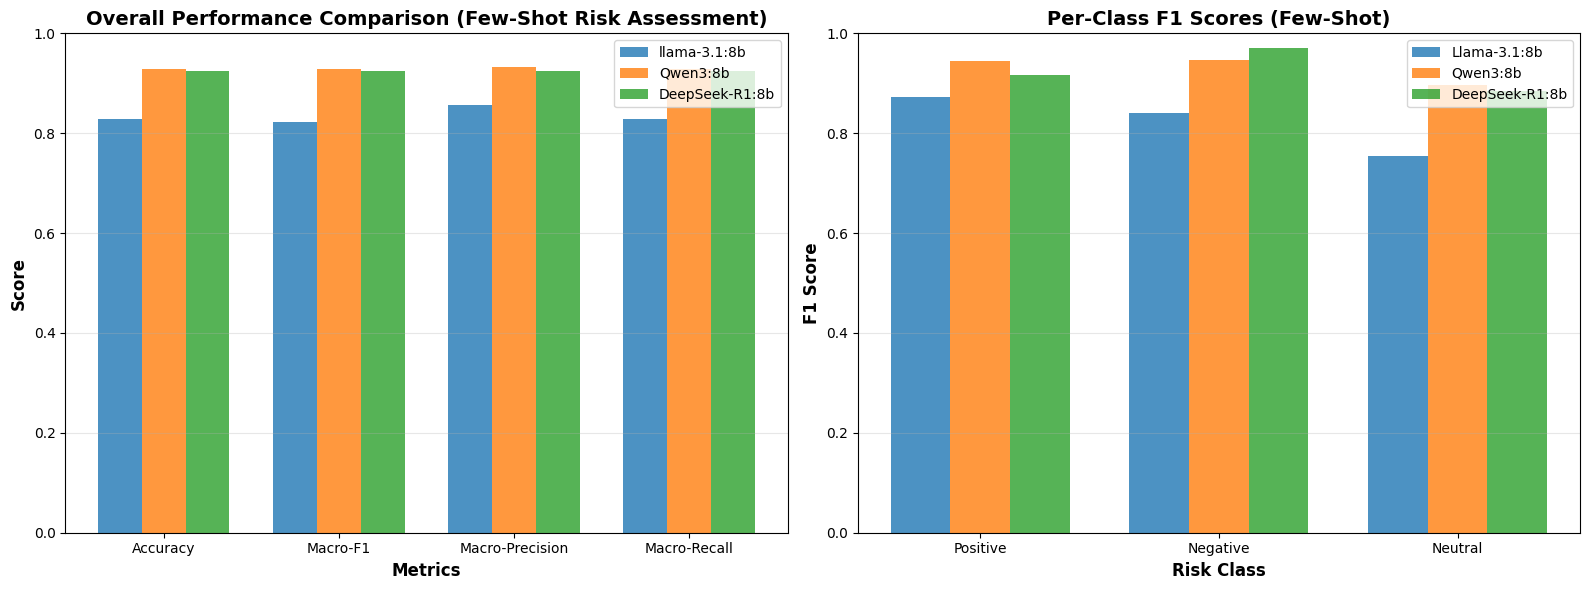

✓ Performance comparison chart saved


In [21]:
# Performance comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall metrics
metrics_to_plot = ["Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (metrics, label) in enumerate(
    [
        (r4_metrics, "llama-3.1:8b"),
        (r5_metrics, "Qwen3:8b"),
        (r6_metrics, "DeepSeek-R1:8b"),
    ]
):
    values = [metrics[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=label, alpha=0.8)

axes[0].set_xlabel("Metrics", fontsize=12, weight="bold")
axes[0].set_ylabel("Score", fontsize=12, weight="bold")
axes[0].set_title(
    "Overall Performance Comparison (Few-Shot Risk Assessment)",
    fontsize=14,
    weight="bold",
)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)

# Per-class F1 scores
classes = ["Positive", "Negative", "Neutral"]
x2 = np.arange(len(classes))

for i, (metrics, label) in enumerate(
    [
        (r4_metrics, "Llama-3.1:8b"),
        (r5_metrics, "Qwen3:8b"),
        (r6_metrics, "DeepSeek-R1:8b"),
    ]
):
    values = [metrics[f"{c}_F1"] for c in classes]
    axes[1].bar(x2 + i * width, values, width, label=label, alpha=0.8)

axes[1].set_xlabel("Risk Class", fontsize=12, weight="bold")
axes[1].set_ylabel("F1 Score", fontsize=12, weight="bold")
axes[1].set_title("Per-Class F1 Scores (Few-Shot)", fontsize=14, weight="bold")
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("few_shot_risk_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Performance comparison chart saved")

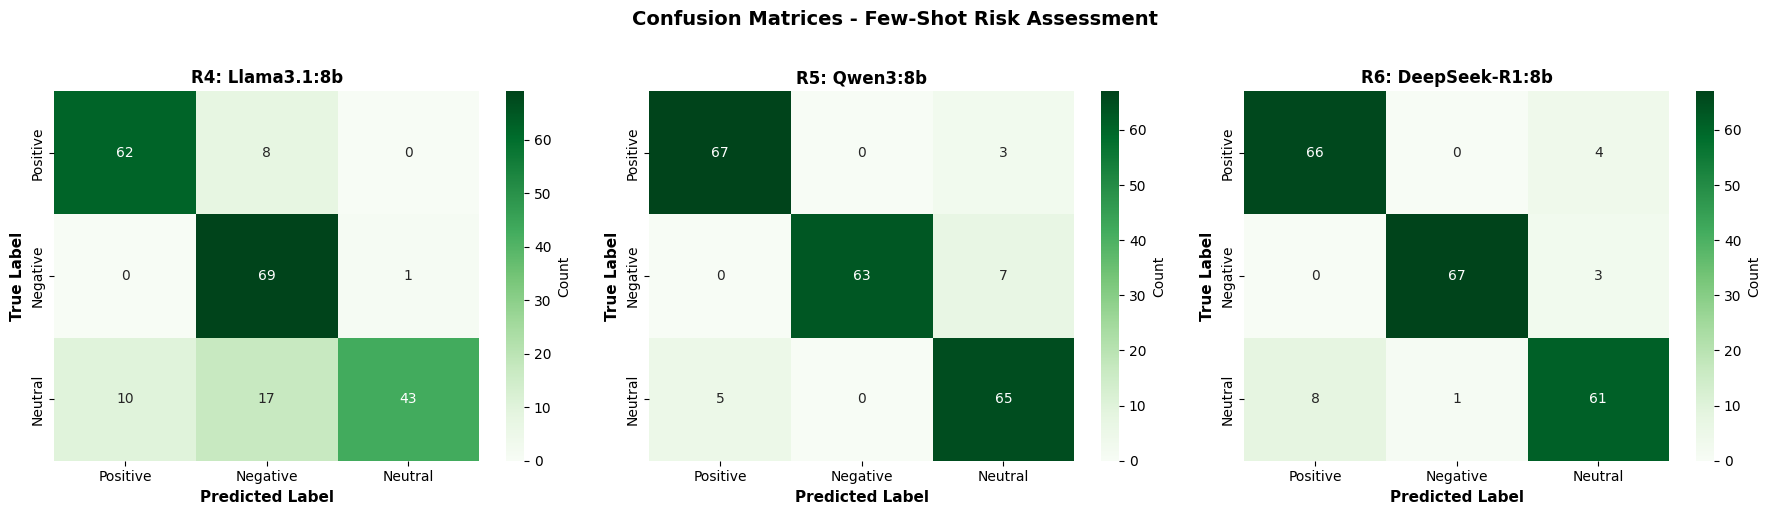

✓ Confusion matrices saved


In [22]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Positive", "Negative", "Neutral"]

for idx, (cm, title) in enumerate(
    [
        (r4_cm, "R4: Llama3.1:8b"),
        (r5_cm, "R5: Qwen3:8b"),
        (r6_cm, "R6: DeepSeek-R1:8b"),
    ]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[idx],
        cbar_kws={"label": "Count"},
    )
    axes[idx].set_title(title, fontsize=12, weight="bold")
    axes[idx].set_ylabel("True Label", fontsize=11, weight="bold")
    axes[idx].set_xlabel("Predicted Label", fontsize=11, weight="bold")

plt.suptitle(
    "Confusion Matrices - Few-Shot Risk Assessment",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("few_shot_risk_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Confusion matrices saved")

## 8. Save Results

In [23]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("\n" + "=" * 80)
print("SAVING RESULTS")
print("=" * 80)

r4_df.to_csv(f"r4_llama3_1_8b_few_shot_risk_{timestamp}.csv", index=False)
print(f"✓ r4_llama3_1_8b_few_shot_risk_{timestamp}.csv")

r5_df.to_csv(f"r5_qwen3_8b_few_shot_risk_{timestamp}.csv", index=False)
print(f"✓ r5_qwen3_8b_few_shot_risk_{timestamp}.csv")

r6_df.to_csv(f"r6_deepseek_r1_8b_few_shot_risk_{timestamp}.csv", index=False)
print(f"✓ r6_deepseek_r1_8b_few_shot_risk_{timestamp}.csv")

metrics_df.to_csv(f"few_shot_risk_metrics_summary_{timestamp}.csv", index=False)
print(f"✓ few_shot_risk_metrics_summary_{timestamp}.csv")

print(f"\n✓ Visualizations saved:")
print(f"  • few_shot_risk_performance_comparison.png")
print(f"  • few_shot_risk_confusion_matrices.png")

print(f"\n🎉 All results saved with timestamp: {timestamp}")


SAVING RESULTS
✓ r4_llama3_1_8b_few_shot_risk_20260224_142800.csv
✓ r5_qwen3_8b_few_shot_risk_20260224_142800.csv
✓ r6_deepseek_r1_8b_few_shot_risk_20260224_142800.csv
✓ few_shot_risk_metrics_summary_20260224_142800.csv

✓ Visualizations saved:
  • few_shot_risk_performance_comparison.png
  • few_shot_risk_confusion_matrices.png

🎉 All results saved with timestamp: 20260224_142800


## 9. Error Analysis

In [24]:
def analyze_errors(df, model_name):
    """Analyze misclassification patterns"""
    errors = df[df["true_risk"] != df["predicted_risk"]].copy()

    print(f"=== Error Analysis for {model_name} ===\n")
    print(
        f"Total errors: {len(errors)}/{len(df)} ({len(errors) / len(df) * 100:.2f}%)\n"
    )

    # Misclassification patterns
    print("Misclassification patterns:")
    confusion_pairs = (
        errors.groupby(["true_risk", "predicted_risk"])
        .size()
        .sort_values(ascending=False)
    )
    for (true_label, pred_label), count in confusion_pairs.items():
        print(
            f"  {true_label} → {pred_label}: {count} ({count / len(errors) * 100:.1f}% of errors)"
        )

    # High-confidence errors (confidence > 0.7)
    if "confidence" in df.columns:
        high_conf_errors = errors[errors["confidence"] > 0.7]
        print(f"\nHigh-confidence errors (conf > 0.7): {len(high_conf_errors)}")
        if len(high_conf_errors) > 0:
            print("\nSample high-confidence errors:")
            for idx in high_conf_errors.head(3).index:
                row = df.loc[idx]
                print(
                    f"  True: {row['true_risk']} | Predicted: {row['predicted_risk']} | Confidence: {row['confidence']:.3f}"
                )
                print(f"  Text: {row['sentence'][:100]}...")
                print()

    # Sample errors by type
    print("\nSample misclassifications:")
    for (true_label, pred_label), _ in confusion_pairs.head(3).items():
        sample = errors[
            (errors["true_risk"] == true_label)
            & (errors["predicted_risk"] == pred_label)
        ].iloc[0]
        print(f"  {true_label} → {pred_label}:")
        print(f"  {sample['sentence'][:120]}...")
        print()

    return errors


# Analyze errors for each model
print("=== R4: Llama3.1:8b-Instruct Few-Shot ===")
r4_errors = analyze_errors(r4_valid, "R4: Llama3.1:8b")

print("\n" + "=" * 80 + "\n")
print("=== R5: Qwen3:8b-Versatile Few-Shot ===")
r5_errors = analyze_errors(r5_valid, "R5: Qwen3:8b")

print("\n" + "=" * 80 + "\n")
print("=== R6: DeepSeek-R1:8b Few-Shot ===")
r6_errors = analyze_errors(r6_valid, "R6: DeepSeek-R1:8b")

=== R4: Llama3.1:8b-Instruct Few-Shot ===
=== Error Analysis for R4: Llama3.1:8b ===

Total errors: 36/210 (17.14%)

Misclassification patterns:
  neutral → negative: 17 (47.2% of errors)
  neutral → positive: 10 (27.8% of errors)
  positive → negative: 8 (22.2% of errors)
  negative → neutral: 1 (2.8% of errors)

High-confidence errors (conf > 0.7): 30

Sample high-confidence errors:
  True: neutral | Predicted: positive | Confidence: 0.850
  Text: The company serves customers in various industries , including process and resources , industrial ma...

  True: neutral | Predicted: positive | Confidence: 0.850
  Text: The aforementioned shareholders have informed that they will propose to the Annual General Meeting t...

  True: neutral | Predicted: positive | Confidence: 0.850
  Text: The Liquid Handling segment offers laboratory equipment and accessories , including mechanical and e...


Sample misclassifications:
  neutral → negative:
  Supported Nokia phones include : N96 , N95-8GB 

## 10. Confidence Calibration Analysis

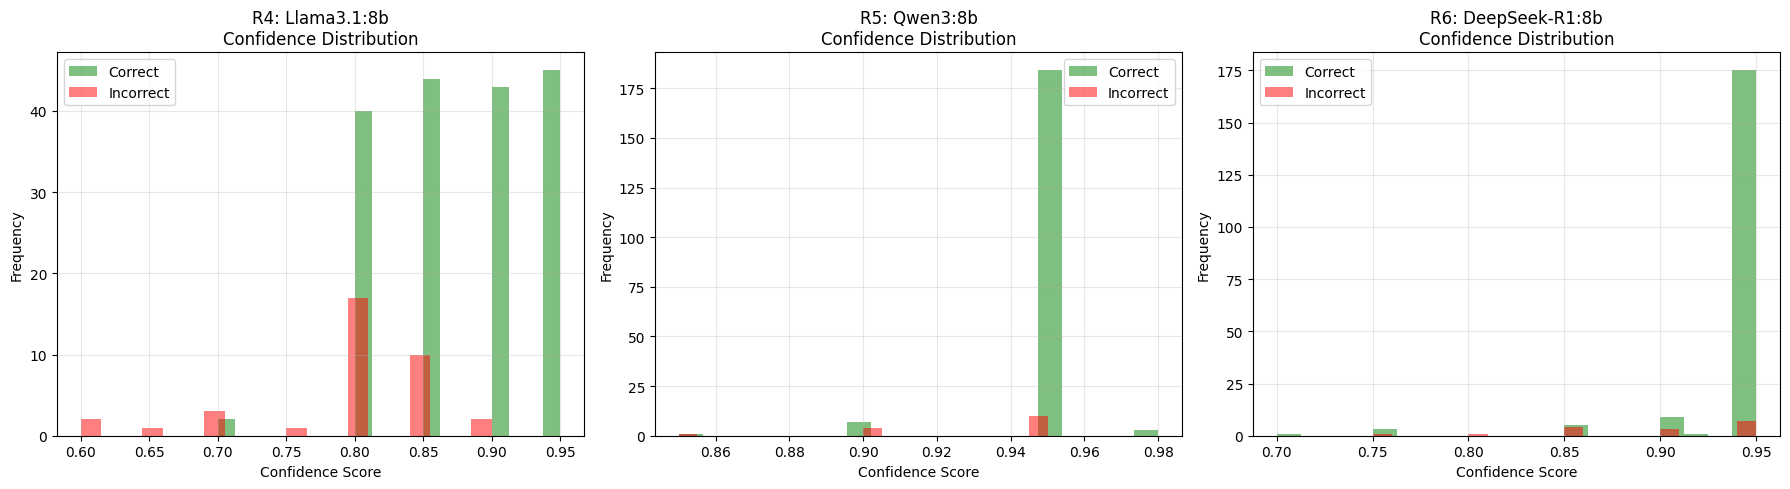

In [25]:
# Visualize confidence distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (valid_df, model_name) in enumerate(
    [
        (r4_valid, "R4: Llama3.1:8b"),
        (r5_valid, "R5: Qwen3:8b"),
        (r6_valid, "R6: DeepSeek-R1:8b"),
    ]
):
    if "confidence" in valid_df.columns:
        correct = valid_df["true_risk"] == valid_df["predicted_risk"]

        axes[idx].hist(
            valid_df[correct]["confidence"],
            bins=20,
            alpha=0.5,
            label="Correct",
            color="green",
        )
        axes[idx].hist(
            valid_df[~correct]["confidence"],
            bins=20,
            alpha=0.5,
            label="Incorrect",
            color="red",
        )
        axes[idx].set_xlabel("Confidence Score")
        axes[idx].set_ylabel("Frequency")
        axes[idx].set_title(f"{model_name}\nConfidence Distribution")
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
def analyze_confidence_calibration(df, model_name):
    """Analyze confidence calibration"""

    if "confidence" not in df.columns:
        print(f"No confidence scores for {model_name}")
        return

    # Overall calibration
    correct = df["true_risk"] == df["predicted_risk"]
    avg_conf_correct = df[correct]["confidence"].mean()
    avg_conf_incorrect = df[~correct]["confidence"].mean()
    calibration_gap = avg_conf_correct - avg_conf_incorrect

    print(f"=== Confidence Calibration: {model_name} ===\n")
    print(f"Average confidence when CORRECT: {avg_conf_correct:.3f}")
    print(f"Average confidence when INCORRECT: {avg_conf_incorrect:.3f}")
    print(f"Calibration gap: {calibration_gap:.3f}")
    print(
        f"  → {'Well-calibrated' if calibration_gap > 0.15 else 'Poorly calibrated'}\n"
    )

    # Per-class confidence
    print("Per-class average confidence:")
    for label in ["positive", "negative", "neutral"]:
        class_mask = df["predicted_risk"] == label
        if class_mask.sum() > 0:
            avg_conf = df[class_mask]["confidence"].mean()
            accuracy = (df[class_mask]["true_risk"] == label).mean()
            print(f"  {label}: {avg_conf:.3f} (accuracy: {accuracy:.3f})")


# Analyze confidence for each model
analyze_confidence_calibration(r4_valid, "R4: Llama3.1:8b")
print("\n" + "=" * 80 + "\n")
analyze_confidence_calibration(r5_valid, "R5: Qwen3:8b")
print("\n" + "=" * 80 + "\n")
analyze_confidence_calibration(r6_valid, "R6: DeepSeek-R1:8b")

=== Confidence Calibration: R4: Llama3.1:8b ===

Average confidence when CORRECT: 0.875
Average confidence when INCORRECT: 0.794
Calibration gap: 0.081
  → Poorly calibrated

Per-class average confidence:
  positive: 0.897 (accuracy: 0.861)
  negative: 0.855 (accuracy: 0.734)
  neutral: 0.816 (accuracy: 0.977)


=== Confidence Calibration: R5: Qwen3:8b ===

Average confidence when CORRECT: 0.948
Average confidence when INCORRECT: 0.930
Calibration gap: 0.018
  → Poorly calibrated

Per-class average confidence:
  positive: 0.951 (accuracy: 0.931)
  negative: 0.950 (accuracy: 1.000)
  neutral: 0.940 (accuracy: 0.867)


=== Confidence Calibration: R6: DeepSeek-R1:8b ===

Average confidence when CORRECT: 0.941
Average confidence when INCORRECT: 0.894
Calibration gap: 0.047
  → Poorly calibrated

Per-class average confidence:
  positive: 0.935 (accuracy: 0.892)
  negative: 0.949 (accuracy: 0.985)
  neutral: 0.927 (accuracy: 0.897)


## 11. Classification Reports

In [27]:
# Create per-class metrics summary table
from sklearn.metrics import precision_recall_fscore_support


def create_metrics_table(y_true, y_pred, model_name):
    """Create a summary table of per-class metrics"""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=["positive", "negative", "neutral"]
    )

    metrics_df = pd.DataFrame(
        {
            "Class": ["positive", "negative", "neutral"],
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "Support": support,
        }
    )

    print(f"\n{model_name} - Per-Class Metrics Summary:")
    print(metrics_df.to_string(index=False))
    return metrics_df


r4_class_metrics = create_metrics_table(
    r4_valid["true_risk"], r4_valid["predicted_risk"], "R4: Llama-3.1-8B"
)
r5_class_metrics = create_metrics_table(
    r5_valid["true_risk"], r5_valid["predicted_risk"], "R5: Qwen3:8b"
)
r6_class_metrics = create_metrics_table(
    r6_valid["true_risk"], r6_valid["predicted_risk"], "R6: DeepSeek-R1:8b"
)


R4: Llama-3.1-8B - Per-Class Metrics Summary:
   Class  Precision   Recall  F1-Score  Support
positive   0.861111 0.885714  0.873239       70
negative   0.734043 0.985714  0.841463       70
 neutral   0.977273 0.614286  0.754386       70

R5: Qwen3:8b - Per-Class Metrics Summary:
   Class  Precision   Recall  F1-Score  Support
positive   0.930556 0.957143  0.943662       70
negative   1.000000 0.900000  0.947368       70
 neutral   0.866667 0.928571  0.896552       70

R6: DeepSeek-R1:8b - Per-Class Metrics Summary:
   Class  Precision   Recall  F1-Score  Support
positive   0.891892 0.942857  0.916667       70
negative   0.985294 0.957143  0.971014       70
 neutral   0.897059 0.871429  0.884058       70


In [28]:
from sklearn.metrics import classification_report

print("=" * 80)
print("R4: Llama3.1:8b Few-Shot Classification Report")
print("=" * 80)
print(
    classification_report(
        r4_valid["true_risk"],
        r4_valid["predicted_risk"],
        target_names=["negative", "neutral", "positive"],
    )
)

print("\n" + "=" * 80)
print("R5: Qwen3:8b Few-Shot Classification Report")
print("=" * 80)
print(
    classification_report(
        r5_valid["true_risk"],
        r5_valid["predicted_risk"],
        labels=["negative", "neutral", "positive"],
        target_names=["negative", "neutral", "positive"],
    )
)

print("\n" + "=" * 80)
print("R6: DeepSeek-R1:8b Few-Shot Classification Report")
print("=" * 80)
print(
    classification_report(
        r6_valid["true_risk"],
        r6_valid["predicted_risk"],
        target_names=["negative", "neutral", "positive"],
    )
)

R4: Llama3.1:8b Few-Shot Classification Report
              precision    recall  f1-score   support

    negative       0.73      0.99      0.84        70
     neutral       0.98      0.61      0.75        70
    positive       0.86      0.89      0.87        70

    accuracy                           0.83       210
   macro avg       0.86      0.83      0.82       210
weighted avg       0.86      0.83      0.82       210


R5: Qwen3:8b Few-Shot Classification Report
              precision    recall  f1-score   support

    negative       1.00      0.90      0.95        70
     neutral       0.87      0.93      0.90        70
    positive       0.93      0.96      0.94        70

    accuracy                           0.93       210
   macro avg       0.93      0.93      0.93       210
weighted avg       0.93      0.93      0.93       210


R6: DeepSeek-R1:8b Few-Shot Classification Report
              precision    recall  f1-score   support

    negative       0.99      0.96      0

## 12. Few-Shot vs Zero-Shot Comparison

Loading zero-shot metrics from: ../Zero_Shot/zero_shot_metrics_summary_20260224_005638.csv

Few-Shot vs Zero-Shot Performance Comparison
         Model  Zero-Shot Accuracy  Few-Shot Accuracy  Accuracy Improvement  Zero-Shot F1 (Macro)  Few-Shot F1 (Macro)  F1 Improvement
  Llama-3.1:8b            0.804762           0.828571              0.023810              0.787422             0.823030        0.035608
      Qwen3:8b            0.866667           0.928571              0.061905              0.863178             0.929194        0.066016
DeepSeek-R1:8b            0.871429           0.923810              0.052381              0.865287             0.923913        0.058626


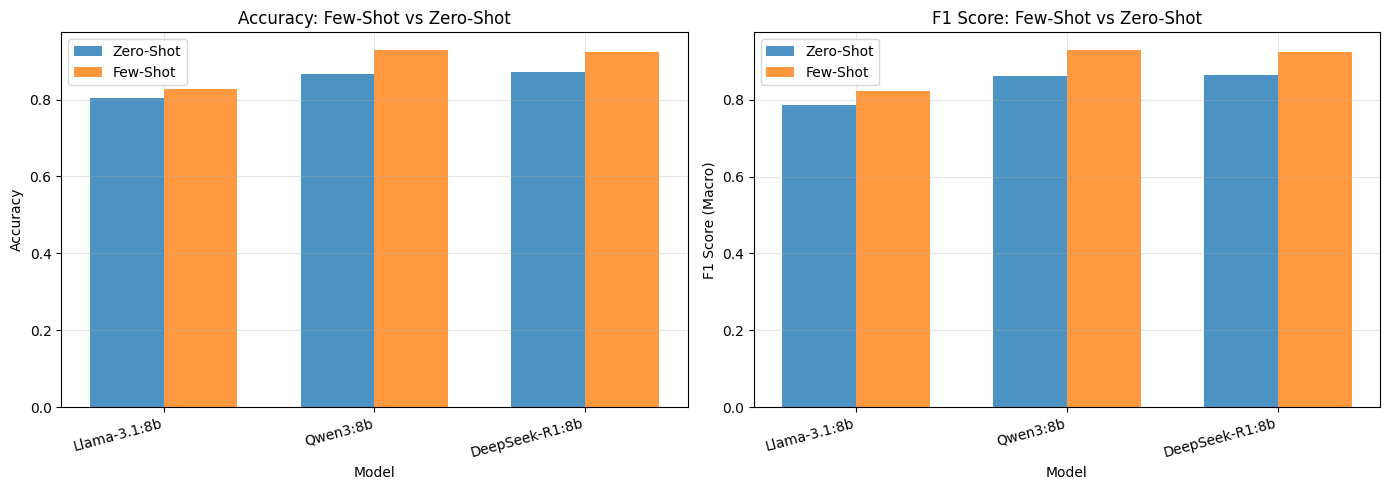


Key Insights from Few-Shot Learning:
1. Largest accuracy improvement: Qwen3:8b (+0.062)
2. Average accuracy improvement: +0.046
3. All models benefited from few-shot examples
4. F1 Score improvements range from 0.036 to 0.066


In [29]:
# Load zero-shot metrics summary for comparison
import os

try:
    # Try to find zero-shot metrics summary file
    zero_shot_dir = "../Zero_Shot/"
    if os.path.exists(zero_shot_dir):
        summary_files = [
            f
            for f in os.listdir(zero_shot_dir)
            if "metrics_summary" in f and f.endswith(".csv")
        ]
        if summary_files:
            zero_shot_summary_path = os.path.join(zero_shot_dir, summary_files[0])
            print(f"Loading zero-shot metrics from: {zero_shot_summary_path}")

            zero_shot_metrics_df = pd.read_csv(zero_shot_summary_path)
            few_shot_metrics_df = metrics_df.copy()

            # Compare metrics
            print("\n" + "=" * 80)
            print("Few-Shot vs Zero-Shot Performance Comparison")
            print("=" * 80)

            comparison_df = pd.DataFrame(
                {
                    "Model": ["Llama-3.1:8b", "Qwen3:8b", "DeepSeek-R1:8b"],
                    "Zero-Shot Accuracy": zero_shot_metrics_df["Accuracy"].values,
                    "Few-Shot Accuracy": few_shot_metrics_df["Accuracy"].values,
                    "Accuracy Improvement": few_shot_metrics_df["Accuracy"].values
                    - zero_shot_metrics_df["Accuracy"].values,
                    "Zero-Shot F1 (Macro)": zero_shot_metrics_df["Macro-F1"].values,
                    "Few-Shot F1 (Macro)": few_shot_metrics_df["Macro-F1"].values,
                    "F1 Improvement": few_shot_metrics_df["Macro-F1"].values
                    - zero_shot_metrics_df["Macro-F1"].values,
                }
            )

            print(comparison_df.to_string(index=False))

            # Visualize improvement
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            x = np.arange(len(comparison_df))
            width = 0.35

            # Accuracy comparison
            axes[0].bar(
                x - width / 2,
                comparison_df["Zero-Shot Accuracy"],
                width,
                label="Zero-Shot",
                alpha=0.8,
            )
            axes[0].bar(
                x + width / 2,
                comparison_df["Few-Shot Accuracy"],
                width,
                label="Few-Shot",
                alpha=0.8,
            )
            axes[0].set_xlabel("Model")
            axes[0].set_ylabel("Accuracy")
            axes[0].set_title("Accuracy: Few-Shot vs Zero-Shot")
            axes[0].set_xticks(x)
            axes[0].set_xticklabels(comparison_df["Model"], rotation=15, ha="right")
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # F1 comparison
            axes[1].bar(
                x - width / 2,
                comparison_df["Zero-Shot F1 (Macro)"],
                width,
                label="Zero-Shot",
                alpha=0.8,
            )
            axes[1].bar(
                x + width / 2,
                comparison_df["Few-Shot F1 (Macro)"],
                width,
                label="Few-Shot",
                alpha=0.8,
            )
            axes[1].set_xlabel("Model")
            axes[1].set_ylabel("F1 Score (Macro)")
            axes[1].set_title("F1 Score: Few-Shot vs Zero-Shot")
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(comparison_df["Model"], rotation=15, ha="right")
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Key insights from comparison
            print("\n" + "=" * 80)
            print("Key Insights from Few-Shot Learning:")
            print("=" * 80)

            best_improvement = comparison_df.loc[
                comparison_df["Accuracy Improvement"].idxmax()
            ]
            print(
                f"1. Largest accuracy improvement: {best_improvement['Model']} (+{best_improvement['Accuracy Improvement']:.3f})"
            )

            avg_improvement = comparison_df["Accuracy Improvement"].mean()
            print(f"2. Average accuracy improvement: +{avg_improvement:.3f}")

            if (comparison_df["Accuracy Improvement"] > 0).all():
                print("3. All models benefited from few-shot examples")
            else:
                print(
                    f"3. {(comparison_df['Accuracy Improvement'] > 0).sum()}/3 models improved with few-shot learning"
                )

            print(
                f"4. F1 Score improvements range from {comparison_df['F1 Improvement'].min():.3f} to {comparison_df['F1 Improvement'].max():.3f}"
            )

        else:
            print("No zero-shot metrics summary file found - skipping comparison")
    else:
        print(f"Zero-shot directory not found: {zero_shot_dir} - skipping comparison")

except Exception as e:
    print(f"Could not load zero-shot metrics for comparison: {e}")
    print("Skipping few-shot vs zero-shot comparison")